In [21]:
import os
import glob
import random
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

# 固定随机种子
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# --- 路径修正区 ---
# 仓库根目录
BASE_DIR = r"D:\Project_Github\Indo-Pacific-humpback-dolphin"
# 数据根目录
DATA_ROOT = BASE_DIR

# 请根据实际情况确认 05 文件夹是在 00_Data 内部还是与其并列
# 方案 A: 如果 05 和 03 文件夹在 00_Data 内部 (基于你的描述推测)
POS_DIR = os.path.join(DATA_ROOT, "05_DistinguishbyEnergy", "Weak_Reverberation")
NEG_DIR = os.path.join(DATA_ROOT, "00_Data","02_ClickDetection", "FalseClick")
HARD_POS_DIR = os.path.join(DATA_ROOT, "03_Distinguish", "Output_Classification", "Severe")

# 检查路径是否存在，如果报错，说明文件夹名字或层级不对
paths = {"正样本": POS_DIR, "负样本": NEG_DIR, "难度正样本": HARD_POS_DIR}
for name, p in paths.items():
    if not os.path.exists(p):
        print(f"❌ 警告: 找不到{name}路径: {p}")
    else:
        print(f"✅ 找到{name}路径: {p}")

✅ 找到正样本路径: D:\Project_Github\Indo-Pacific-humpback-dolphin\05_DistinguishbyEnergy\Weak_Reverberation
✅ 找到负样本路径: D:\Project_Github\Indo-Pacific-humpback-dolphin\00_Data\02_ClickDetection\FalseClick
✅ 找到难度正样本路径: D:\Project_Github\Indo-Pacific-humpback-dolphin\03_Distinguish\Output_Classification\Severe


In [22]:
def get_all_wavs(directory):
    # 同时匹配 .wav 和 .WAV
    files = glob.glob(os.path.join(directory, "**", "*.wav"), recursive=True)
    files.extend(glob.glob(os.path.join(directory, "**", "*.WAV"), recursive=True))
    return files

# 1. 获取正样本 (目标 884)
all_pos_files = get_all_wavs(POS_DIR)
if len(all_pos_files) == 0:
    raise ValueError(f"在 {POS_DIR} 下没找到任何wav文件，请检查文件夹内容！")

selected_pos = all_pos_files[:884]

# 2. 获取负样本并采样 (884 + 100)
all_neg_files = get_all_wavs(NEG_DIR)
if len(all_neg_files) < 984:
    print(f"⚠️ 警告: 负样本总数({len(all_neg_files)})不足 984 个，将使用全部负样本。")

random.shuffle(all_neg_files)
selected_neg_main = all_neg_files[:len(selected_pos)] # 保持与正样本 1:1
selected_neg_hard = all_neg_files[len(selected_pos) : len(selected_pos)+100]

# 3. 获取难度测试集正样本 (100)
all_hard_pos_files = get_all_wavs(HARD_POS_DIR)
if len(all_hard_pos_files) == 0:
    print(f"⚠️ 警告: {HARD_POS_DIR} 下没找到难度正样本！")
selected_hard_pos = all_hard_pos_files[:100]

print(f"\n文件检索完成:")
print(f" - 主正样本: {len(selected_pos)} 个")
print(f" - 主负样本: {len(selected_neg_main)} 个")
print(f" - 难度正样本: {len(selected_hard_pos)} 个")
print(f" - 难度负样本: {len(selected_neg_hard)} 个")


文件检索完成:
 - 主正样本: 884 个
 - 主负样本: 884 个
 - 难度正样本: 100 个
 - 难度负样本: 100 个


In [23]:
def load_and_preprocess(file_list, target_length=512, augment=True):
    if not file_list:
        return np.empty((0, target_length)) # 返回正确形状的空数组
        
    data = []
    for f in file_list:
        try:
            # sr=None 保证原始采样率，不进行重采样以提高速度
            y, sr = librosa.load(f, sr=None)
            
            # 统一长度
            if len(y) > target_length:
                y = y[:target_length]
            else:
                y = np.pad(y, (0, max(0, target_length - len(y))), 'constant')
            
            # 随机平移增强
            if augment:
                shift = np.random.randint(-50, 50)
                y = np.roll(y, shift)
                
            data.append(y)
        except Exception as e:
            print(f"无法读取文件 {f}: {e}")
            
    return np.array(data)

WAVE_LEN = 512 # 根据你的Click信号长度调整，通常512个采样点足够

print("正在加载并处理音频波形...")
X_pos = load_and_preprocess(selected_pos, target_length=WAVE_LEN)
X_neg = load_and_preprocess(selected_neg_main, target_length=WAVE_LEN)
X_hard_pos = load_and_preprocess(selected_hard_pos, target_length=WAVE_LEN, augment=False)
X_hard_neg = load_and_preprocess(selected_neg_hard, target_length=WAVE_LEN, augment=False)

# 确保数组不是空的再合并
if X_pos.shape[0] > 0 and X_neg.shape[0] > 0:
    X = np.vstack([X_pos, X_neg])
    y = np.array([1]*len(X_pos) + [0]*len(X_neg))
    print(f"主数据集准备就绪: X.shape = {X.shape}")
else:
    print("❌ 错误: 主数据集为空，请检查路径和文件加载结果。")

if X_hard_pos.shape[0] > 0 and X_hard_neg.shape[0] > 0:
    X_hard = np.vstack([X_hard_pos, X_hard_neg])
    y_hard = np.array([1]*len(X_hard_pos) + [0]*len(X_hard_neg))
    print(f"难度测试集准备就绪: X_hard.shape = {X_hard.shape}")

正在加载并处理音频波形...
主数据集准备就绪: X.shape = (1768, 512)
难度测试集准备就绪: X_hard.shape = (200, 512)


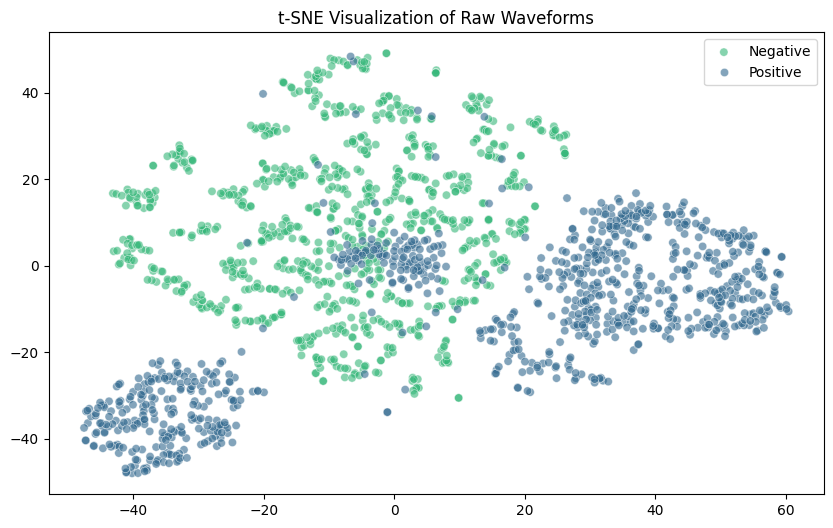

In [24]:
tsne = TSNE(n_components=2, random_state=SEED, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=y, palette='viridis', alpha=0.6)
plt.title("t-SNE Visualization of Raw Waveforms")
plt.legend(["Negative", "Positive"])
plt.show()

In [25]:
# 8:2 分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

# 初始化 XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=SEED,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 5折交叉验证
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='accuracy')

print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

d:\Python_env\Detector\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:54:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Python_env\Detector\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:54:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Python_env\Detector\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:54:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Python_env\Detector\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:54:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, ite

5-Fold CV Accuracy: 0.9604 (+/- 0.0085)


In [26]:
# 训练模型
xgb_model.fit(X_train, y_train)

# 测试集预测
y_pred = xgb_model.predict(X_test)

print("Classification Report on Test Set (20%):")
print(classification_report(y_test, y_pred, target_names=['FalseClick', 'PositiveClick']))

d:\Python_env\Detector\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:54:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report on Test Set (20%):
               precision    recall  f1-score   support

   FalseClick       0.97      0.92      0.94       177
PositiveClick       0.92      0.97      0.95       177

     accuracy                           0.95       354
    macro avg       0.95      0.95      0.95       354
 weighted avg       0.95      0.95      0.95       354



Classification Report on Hard Test Set (Severe Reverberation):
               precision    recall  f1-score   support

   FalseClick       0.99      0.96      0.97       100
PositiveClick       0.96      0.99      0.98       100

     accuracy                           0.97       200
    macro avg       0.98      0.97      0.97       200
 weighted avg       0.98      0.97      0.97       200



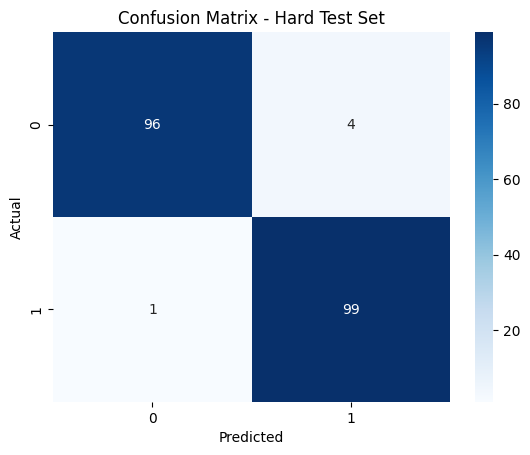

In [ ]:
# 难度测试集预测
y_hard_pred = xgb_model.predict(X_hard)

print("Classification Report on Hard Test Set (Severe Reverberation):")
print(classification_report(y_hard, y_hard_pred, target_names=['FalseClick', 'PositiveClick']))
print(classification_report(y_hard, y_hard_pred, target_names=['FalseClick', 'PositiveClick']))

# 可视化混淆矩阵 (可选)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_hard, y_hard_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Hard Test Set')
plt.show()